# Projeto Imobiliária

Nós fomos contratados como cientistas de dados de uma empresa imobiliária. Nossa principal função é dar suporte as demandas do time de Machine Learning e do time de Desenvolvimento dessa empresa.

Para atendermos essas demandas, foi disponibilizado um board no Trello, com as etapas e tarefas do projeto que devemos realizar. Também foi disponibilizada uma base de dados, que utilizaremos para desenvolver o projeto.

## 1 Etapa do projeto

- O primeiro passo para começarmos o projeto é importar a base de dados e verificar algumas características gerais, como:

1. quantidade de linhas e colunas;

2. quais as colunas da base de dados;

3. explorar as diferentes colunas existentes;

4. verificar os tipos dos dados.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'
df = pd.read_csv(url, sep=';')

df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN


In [ ]:
# Fazendo uma exploração dos dados, variáveis e seus tipos na base de dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  object 
 1   Bairro      32960 non-null  object 
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.3+ MB


Verificamos que é uma base de dados bem considerável no quesito de informações contendo:

- 32.960 linhas / 8 colunas
- 4 colunas com os tipos de dados inteiros
- 3 colunas com os tipos de dados float
- 2 colunas com os tipos de dados textuais

Temos também algumas colunas com dados nulos, onde iremos ver melhor mais a frente.

# 2 Etapa do projeto

O processo de Análise Exploratória de Dados (EDA) consiste em buscar entender como são estruturados os dados que queremos analisar.

É um processo de caráter investigativo, onde tentamos compreender várias características, como: os valores presentes nas colunas, os tipos de estrutura de dados, verificar se são dados qualitativos ou quantitativos, se há valores faltantes ou incomuns.

Por isso, nesse momento, perguntas sobre os dados são sempre bem-vindas. Elas irão guiar todo o processo de análise, e, através das ferramentas disponíveis, como o nosso querido Pandas, iremos buscar por respostas.

Algumas perguntas que podemos fazer nesse momento:

Quais os valores médios de aluguel por tipo de imóvel?

Qual o percentual de cada tipo de imóvel na nossa base de dados?

In [ ]:
df.groupby('Tipo').mean(numeric_only=True)

,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
Tipo,,,,,,,
Apartamento,2.481569,1.232388,0.875998,119.790498,4744.614648,1722.653697,686.170413
Box/Garagem,0.060976,1.304878,0.000000,17.524390,1899.756098,305.450000,125.846154
Casa,3.133402,1.795243,1.258532,250.578077,6793.454922,931.280952,1582.506394
Casa Comercial,1.562264,2.203774,0.260377,372.241509,14478.264151,1935.709677,1707.386740
Casa de Condomínio,4.007028,3.101406,2.864458,456.161647,11952.061245,1342.025527,3252.517730
Casa de Vila,1.927711,0.389558,0.228916,78.469880,1574.369478,138.768421,183.878788
Chácara,3.000000,0.000000,0.000000,0.000000,4900.000000,NaN,NaN
Conjunto Comercial/Sala,0.040939,2.516801,0.010858,214.472487,14715.045521,4512.218100,1399.596571
Flat,1.415966,0.962185,0.754202,65.483193,4546.189076,2027.720554,493.166667


In [ ]:
# Aplicando o mean apenas na coluna "valor" que é o que queremos saber

df_preco_tipo = df.groupby('Tipo')[['Valor']].mean().sort_values('Valor')
df_preco_tipo

,Valor
Tipo,
Quitinete,1246.840909
Pousada/Chalé,1480.000000
Casa de Vila,1574.369478
Box/Garagem,1899.756098
Studio,2400.000000
Loft,2557.882353
Flat,4546.189076
Apartamento,4744.614648
Chácara,4900.000000


<Axes: ylabel='Tipo'>

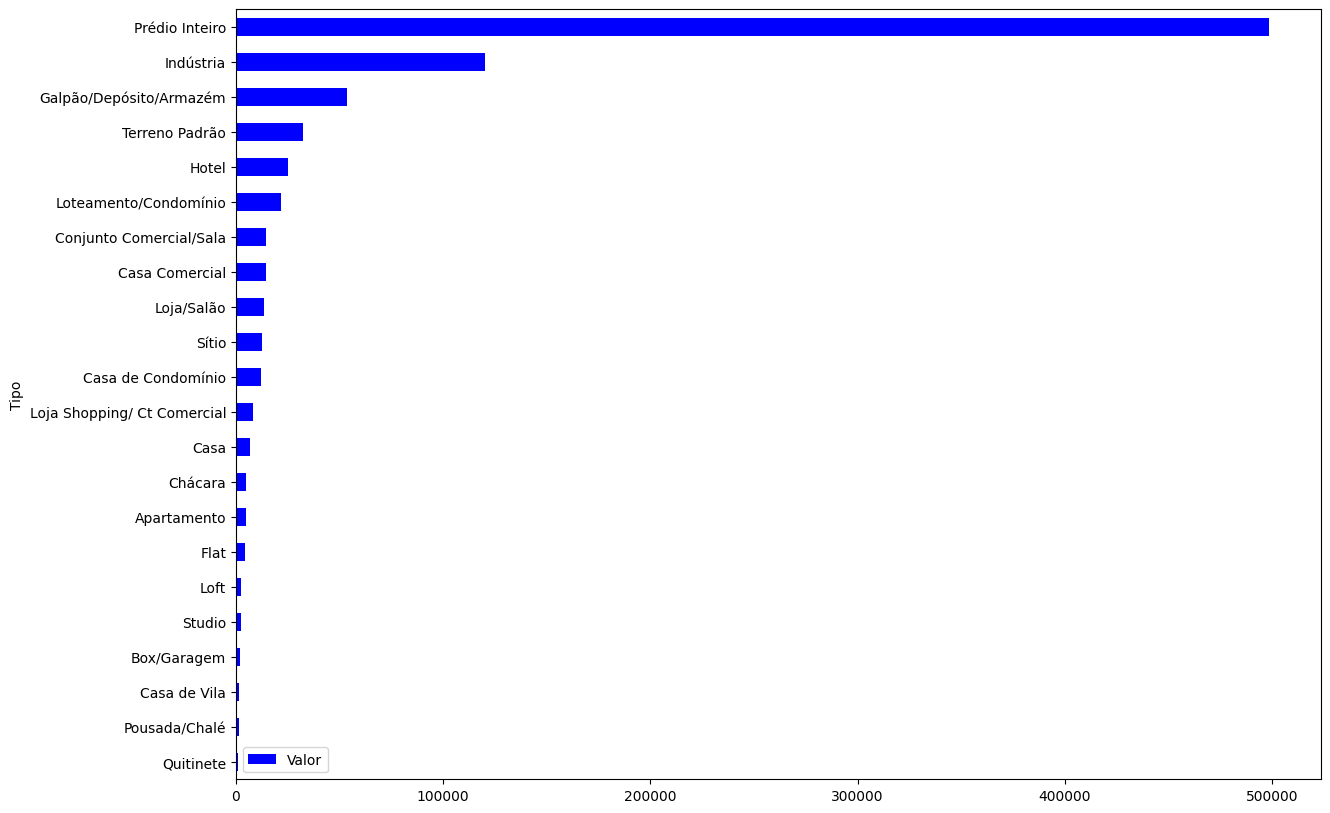

In [ ]:
# plotando em um gráfico esse resultado

df_preco_tipo = df.groupby('Tipo')[['Valor']].mean().sort_values('Valor')

df_preco_tipo.plot(kind='barh', figsize=(14, 10 ), color='blue')

#### Alerta 1

Podemos ver uma grande discrepância e que possuimos outliers, como o foco é analisar os imóveis residenciais, nessa base de dados faz sentido remover os outliers para que eles não influênciem nos modelos que serão construidos futuramente.

In [ ]:
## Removendo os imóveis comerciais, mas primeiro vizualizando quais são e colocando-os em uma lista separada

df.Tipo.unique()

array(['Quitinete', 'Casa', 'Conjunto Comercial/Sala', 'Apartamento',
       'Casa de Condomínio', 'Prédio Inteiro', 'Flat', 'Loja/Salão',
       'Galpão/Depósito/Armazém', 'Casa Comercial', 'Casa de Vila',
       'Terreno Padrão', 'Box/Garagem', 'Loft',
       'Loja Shopping/ Ct Comercial', 'Chácara', 'Loteamento/Condomínio',
       'Sítio', 'Pousada/Chalé', 'Studio', 'Hotel', 'Indústria'],
      dtype=object)

In [ ]:
imoveis_comerciais = ['Conjunto Comercial/Sala',
        'Prédio Inteiro', 'Loja/Salão',
       'Galpão/Depósito/Armazém', 'Casa Comercial',
       'Terreno Padrão', 'Box/Garagem',
       'Loja Shopping/ Ct Comercial', 'Chácara', 'Loteamento/Condomínio',
       'Sítio', 'Pousada/Chalé', 'Studio', 'Hotel', 'Indústria']

In [ ]:
df_trabalhado = df.query('@imoveis_comerciais not in Tipo')
df_trabalhado

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
32953,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


In [ ]:
#Para verificar se deu tudo certo

df_trabalhado.Tipo.unique()

array(['Quitinete', 'Casa', 'Apartamento', 'Casa de Condomínio', 'Flat',
       'Casa de Vila', 'Loft'], dtype=object)

<Axes: ylabel='Tipo'>

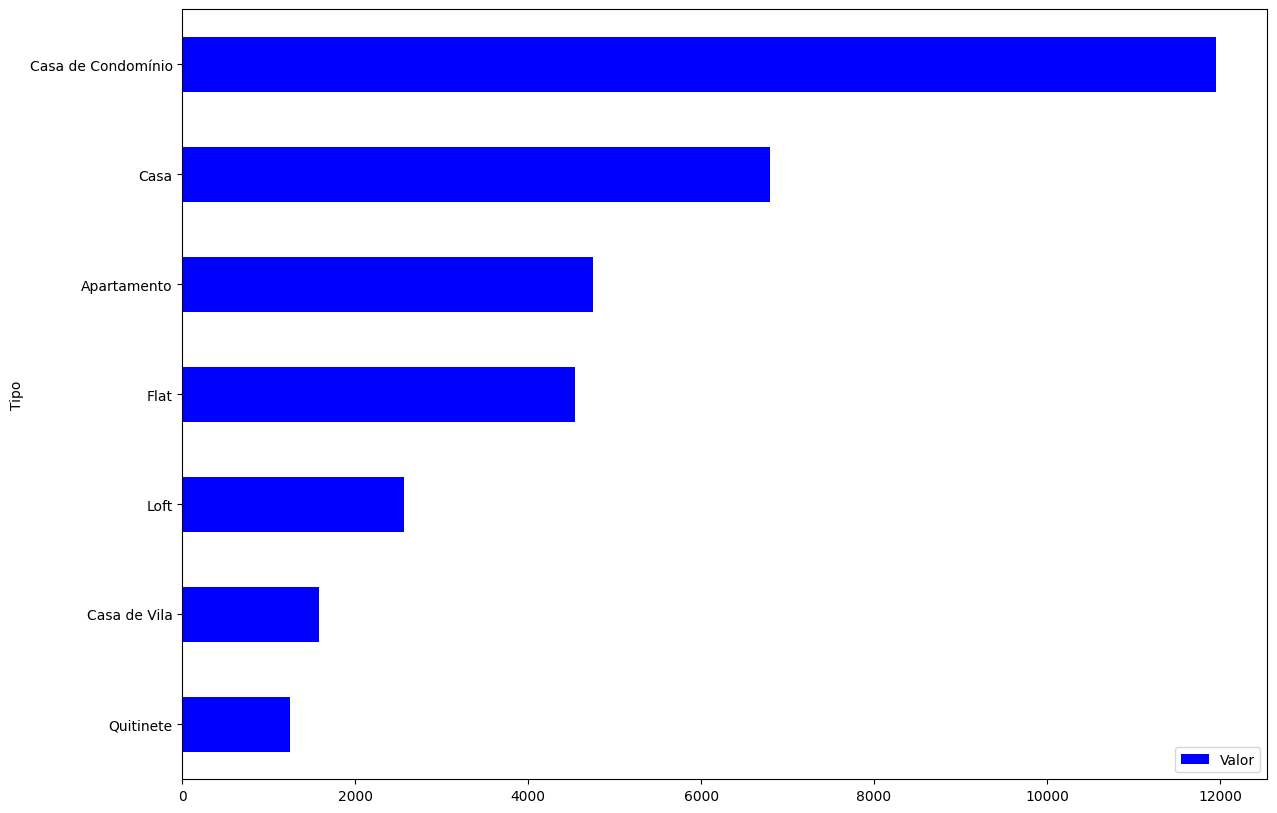

In [ ]:
df_preco_tipo = df_trabalhado.groupby('Tipo')[['Valor']].mean().sort_values('Valor')

df_preco_tipo.plot(kind='barh', figsize=(14, 10 ), color='blue')

Agora já conseguimos trabalhar de uma forma mais direcionada e expecífica.


Mas ainda temos que responder à pergunta:

- Qual o percentual de cada tipo de imóvel na nossa base de dados?

In [ ]:
df_trabalhado['Tipo'].value_counts()

,count
Tipo,
Apartamento,19532
Casa de Condomínio,996
Casa,967
Quitinete,836
Flat,476
Casa de Vila,249
Loft,51


In [ ]:
# Convertendo uma série em um dataframe para conseguirmos colocar em percentual os values counts

In [ ]:
df_percentual = df_trabalhado['Tipo'].value_counts(normalize=True).to_frame()
df_percentual

,proportion
Tipo,
Apartamento,0.845285
Casa de Condomínio,0.043104
Casa,0.041849
Quitinete,0.036180
Flat,0.020600
Casa de Vila,0.010776
Loft,0.002207


<Axes: xlabel='Tipos', ylabel='Percentual'>

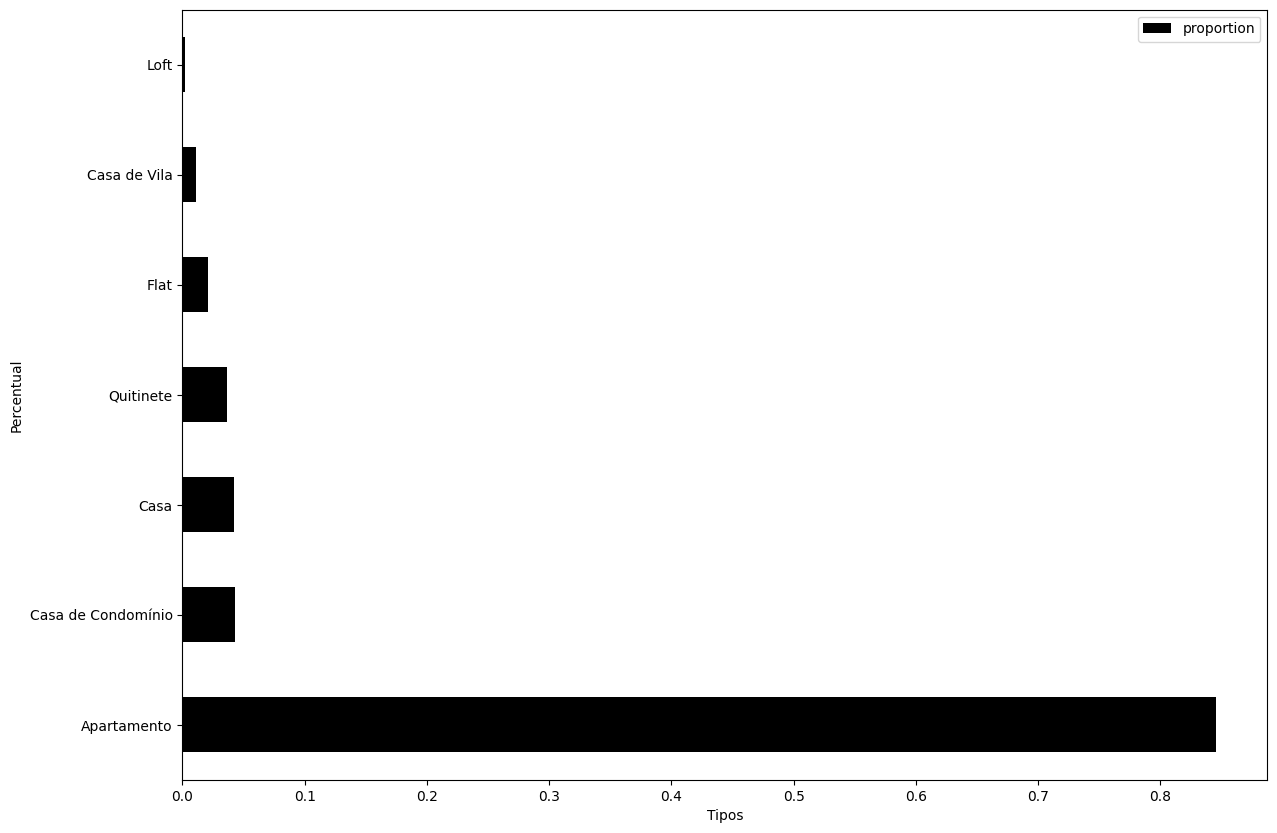

In [ ]:
# Vamos então plotar essa informação em um gráfico para melhorar a visualização

df_percentual = df_trabalhado['Tipo'].value_counts(normalize=True).to_frame()

df_percentual.plot(kind='barh', figsize=(14, 10), color = 'black', xlabel = 'Tipos', ylabel= 'Percentual')

#### Alerta 2
Encontramos mais uma discrepância aqui, grande parte da base de dados é ocupada pelo imóvel do tipo 'Apartamento', os outros tipos não ocupam nem 10% da base, ou seja nesse contexto faz mais sentido fazer as análises considerando apenas os apartamentos.

In [ ]:
df = df.query('Tipo == "Apartamento"')
df.head()


,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
11,Apartamento,Grajaú,2,1,0,70,1500.0,642.0,74.0
12,Apartamento,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0


### Respondendo algumas perguntas extras do time me ML

1) Calcular a média de quartos dos imóveis;

In [ ]:
df['Quartos'].mean()

np.float64(2.499094781682641)

- Não existe 2 quartos e meio, e como o número de ponto flutuante é 4 (abaixo de 5) podemos arredondar para 2, ou seja em média a quantidade de quartos nos imóveis do tipo apartamento são 2.

2) Conferir quantos bairros únicos existem na nossa base de dados;

In [ ]:
# Minha forma:

df['Bairro'].value_counts()

,count
Bairro,
Barra da Tijuca,3282
Copacabana,2349
Ipanema,1732
Recreio dos Bandeirantes,1467
Leblon,1222
...,...
Anchieta,1
Cavalcanti,1
Cidade Jardim,1


In [ ]:
# A correção
len(df['Bairro'].unique())

145

- Existem 149 Bairros únicos na nosssa base de dados

3) Analisar quais bairros possuem a média de valor de aluguel mais elevadas;

In [ ]:
top5_bairros = df.groupby('Bairro')[['Valor']].mean().sort_values('Valor', ascending=False).head(5)
top5_bairros

,Valor
Bairro,
Joá,15500.000000
Arpoador,12923.916667
Cidade Jardim,12000.000000
Botafogo,9497.491569
Ipanema,9465.173210


- Os bairros que possuem média elevada são: Joá, Arpoador, Cidade Jardim, Ipanema e Botafogo.

4) Criar um gráfico de barras horizontais que apresente os 5 bairros com as médias de valores de aluguel mais elevadas.

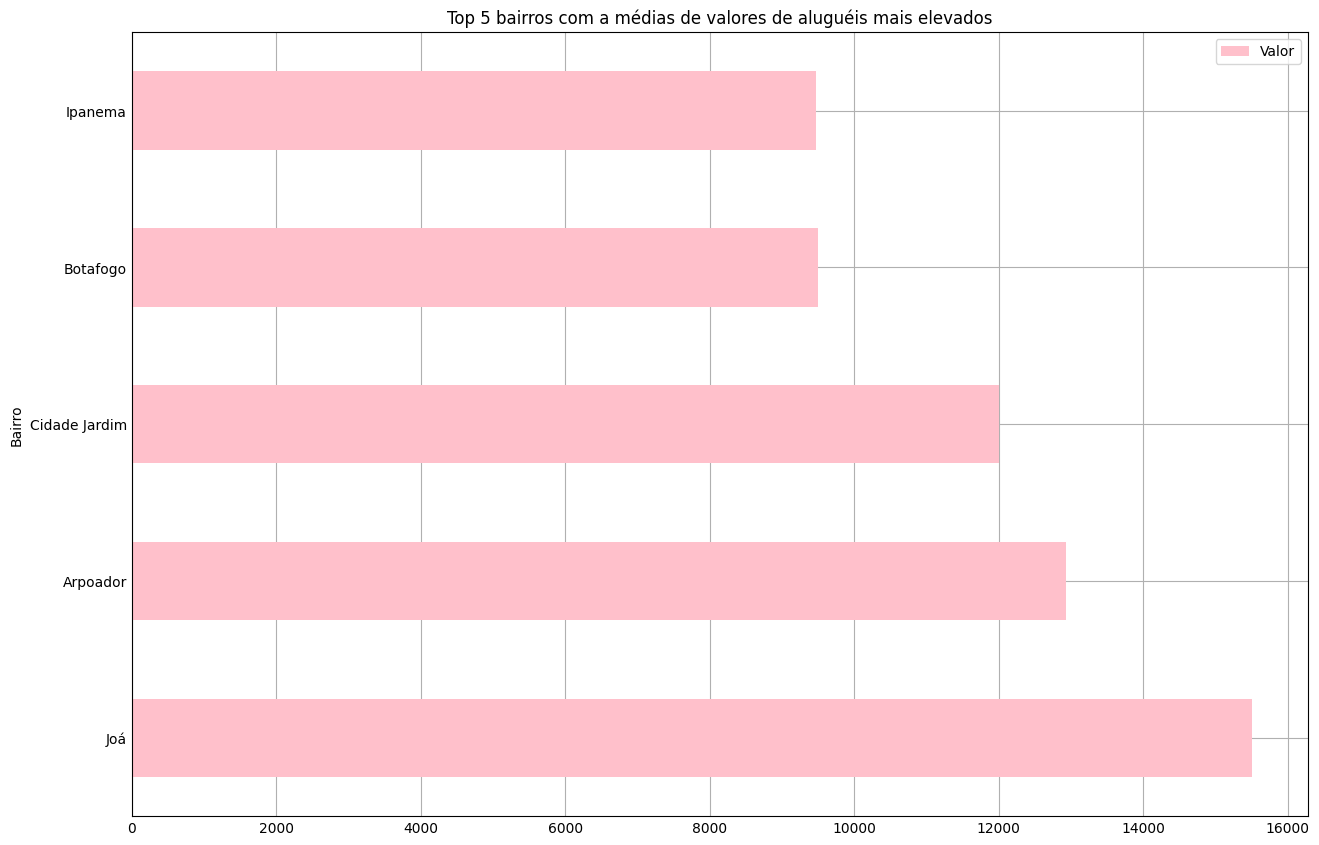

In [ ]:
top5_bairros.plot(kind='barh', figsize=(12, 8 ), color = 'pink')

plt.style.use('_mpl-gallery')
plt.title('Top 5 bairros com a médias de valores de aluguéis mais elevados')
plt.xlabel=('Valor')
plt.ylabel=("Bairro")



### Durante este processo passamos por diversos aprendizados, tais como:

- Identificar o que fazer durante um processo de análise exploratória;
- Calcular a média de valores de um DataFrame;
- Agrupar os dados de acordo com uma coluna específica utilizando o groupby;
- Fazer seleções utilizando o método query;
- Transformar Series em DataFrames;
- Ordenar valores de um DataFrame com o sort_values;
- Plotar gráficos de barras verticais e horizontais;
- Visualizar valores únicos com o unique;
- Utilizar o value_counts para contar valores únicos e calcular percentuais;
- Mudar nomes de colunas.

## 3 Etapa do projeto

Como nossos dados serão usados pelo time de ML para criação de um modelo de precificação de imóveis, é importante tratarmos os dados nulos, uma vez que dados nulos não podem ser utilizados no treinamento de modelos de ML.

- Lidando com dados nulos

In [ ]:
df.isnull()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False
11,False,False,False,False,False,False,False,False,False
12,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
32951,False,False,False,False,False,False,False,False,False
32953,False,False,False,False,False,False,False,False,False
32956,False,False,False,False,False,False,False,False,False
32957,False,False,False,False,False,False,False,False,False


Essa não é a melhor maneira de visualizar os valores nulos existentes no dataset 👎

In [ ]:
## Essa é a melhor forma de ter uma visão geral dos dados nulos existentes no dataset

df.isnull().sum()

,0
Tipo,0
Bairro,0
Quartos,0
Vagas,0
Suites,0
Area,0
Valor,0
Condominio,0
IPTU,0


Neste contexto, como todas as variavéis que possuem dados nulos são variáveis numéricas, podemos utilizar nosso amigo '0' para preenche-los.

In [ ]:
df.fillna(0)

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
11,Apartamento,Grajaú,2,1,0,70,1500.0,642.0,74.0
12,Apartamento,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
...,...,...,...,...,...,...,...,...,...
32951,Apartamento,Vila Valqueire,2,0,0,52,1000.0,550.0,0.0
32953,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


In [ ]:
# Fixando a mudança atribuindo o novo df ao ppróprio df

df = df.fillna(0)
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
11,Apartamento,Grajaú,2,1,0,70,1500.0,642.0,74.0
12,Apartamento,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
...,...,...,...,...,...,...,...,...,...
32951,Apartamento,Vila Valqueire,2,0,0,52,1000.0,550.0,0.0
32953,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


In [ ]:
# Conferindo se deu tudo certo

df.isnull().sum()

,0
Tipo,0
Bairro,0
Quartos,0
Vagas,0
Suites,0
Area,0
Valor,0
Condominio,0
IPTU,0


Pronto, dados nulos tratados. Agora quando nosso tipo fizer operações matemáticas utilizando modelos de ML, eles não terão problemas com esses missing data.

- Lidando com dados inconsistentes

Alguns registros existentes na base de dados não fazem muito sentido, por exemplo:

- apartamentos que possuem valor de aluguel igual a 0;
- apartamentos com o valor do condomínio igual a 0.

Esses registros são inconsistentes, por isso devemos removê-los da nossa base de dados.

In [ ]:
df.query('Valor == 0 | Condominio ==  0')

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU


In [ ]:
df.query('Valor == 0')

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU


In [ ]:
# Pegando os indíces das linhas que precisamos remover

df.query('Valor == 0 | Condominio ==  0').index

Index([], dtype='int64')

In [ ]:
# Removendo os registros definitivamente

registros_a_remover = df.query('Valor == 0 | Condominio ==  0').index

df.drop(registros_a_remover, axis=0, inplace=True)

In [ ]:
#Verificando se foram todos removidos mesmo

df.query('Valor == 0 | Condominio ==  0')

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU


## Será que existe algo a mais na base que possa ser removido?

In [ ]:
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
11,Apartamento,Grajaú,2,1,0,70,1500.0,642.0,74.0
12,Apartamento,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0


Como já sabemos exatamente o tipo de imóvel que estamos trabalhando "Apartamente" e só existe esse tipo na nossa nova base, não faz sentido deixar essa coluna também consumindo memória a toa né?!

In [ ]:
df.Tipo.unique()

array(['Apartamento'], dtype=object)

In [ ]:
# Removendo essa coluna

df.drop('Tipo', axis=1, inplace=True)

In [ ]:
#Verificando se ela foi removida

df.head()

,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Centro,1,0,0,15,800.0,390.0,20.0
4,Higienópolis,1,0,0,48,800.0,230.0,0.0
6,Cachambi,2,0,0,50,1300.0,301.0,17.0
11,Grajaú,2,1,0,70,1500.0,642.0,74.0
12,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0


### Parte 3 do projeto

- Aplicando filtros:

Nesse momento, o time de ML deseja avaliar apenas imóveis em cenários específicos, como:

1. Apartamentos que possuem 1 quarto e aluguel menor que R$ 1200;

2. Apartamentos que possuem pelo menos 2 quartos, aluguel menor que R$ 3000 e área maior que 70 m².

Com base nisso, precisamos aplicar os filtros necessários para obter essas informações específicas.

In [ ]:
df['Quartos'] == 1

,Quartos
3,True
4,True
6,False
11,False
12,False
...,...
32951,False
32953,False
32956,False
32957,False


In [ ]:
# De uma forma mais manual,  vamos armazenar essa seleção em uma variável

selecao1 = df['Quartos'] == 1
df[selecao1]

,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Centro,1,0,0,15,800.0,390.0,20.0
4,Higienópolis,1,0,0,48,800.0,230.0,0.0
13,Copacabana,1,0,1,40,2000.0,561.0,50.0
28,Tijuca,1,0,0,48,750.0,772.0,25.0
54,Centro,1,0,0,27,750.0,371.0,19.0
...,...,...,...,...,...,...,...,...
32918,Ipanema,1,0,0,55,2000.0,630.0,19.0
32922,Barra da Tijuca,1,1,0,62,1700.0,945.0,180.0
32935,Leblon,1,1,1,50,4300.0,1730.0,259.0
32938,Copacabana,1,0,0,50,1950.0,450.0,70.0


In [ ]:
selecao2 = df['Valor'] < 1200
df[selecao2]

,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Centro,1,0,0,15,800.0,390.0,20.0
4,Higienópolis,1,0,0,48,800.0,230.0,0.0
19,Freguesia (Jacarepaguá),3,0,0,54,950.0,300.0,28.0
23,Olaria,3,1,0,68,1000.0,670.0,0.0
28,Tijuca,1,0,0,48,750.0,772.0,25.0
...,...,...,...,...,...,...,...,...
32925,Campinho,2,0,0,63,800.0,392.0,0.0
32930,Freguesia (Jacarepaguá),2,1,0,60,500.0,900.0,148.0
32950,Tijuca,1,0,0,28,1000.0,360.0,25.0
32951,Vila Valqueire,2,0,0,52,1000.0,550.0,0.0


In [ ]:
## Agora vamos juntar as duas seleções

selecao_final = (selecao1) & (selecao2)
df[selecao_final]

,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Centro,1,0,0,15,800.0,390.0,20.0
4,Higienópolis,1,0,0,48,800.0,230.0,0.0
28,Tijuca,1,0,0,48,750.0,772.0,25.0
54,Centro,1,0,0,27,750.0,371.0,19.0
94,Centro,1,1,0,37,1100.0,540.0,900.0
...,...,...,...,...,...,...,...,...
32596,Grajaú,1,0,1,37,1000.0,200.0,0.0
32617,Pechincha,1,0,1,69,900.0,640.0,126.0
32627,Glória,1,0,0,46,1100.0,453.0,32.0
32714,Botafogo,1,0,0,21,1000.0,282.0,25.0


In [ ]:
#Podemos falvar essa seleção em uma variável para ficar mais acessível para o time de ML

df_filtro2 = df[selecao_final]

O próximo filtro é: **Apartamentos que possuem pelo menos 2 quartos, aluguel menor que R$ 3000 e área maior que 70 m².**

Mas dessa vez podemos utilizar uma forma mais automatica

In [ ]:
selecao = (df['Quartos'] >= 2) & (df['Valor'] < 3000) & (df['Area'] > 70)
df[selecao]

,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
12,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
21,Tijuca,2,1,0,110,1900.0,700.0,138.0
24,Tijuca,2,1,0,78,2000.0,700.0,0.0
32,Botafogo,2,1,0,76,2500.0,740.0,0.0
36,Recreio dos Bandeirantes,3,1,1,105,2300.0,648.0,0.0
...,...,...,...,...,...,...,...,...
32934,Jacarepaguá,2,1,1,78,2200.0,790.0,180.0
32940,Barra da Tijuca,2,1,1,85,2250.0,1561.0,197.0
32941,Barra da Tijuca,3,2,0,98,2300.0,887.0,177.0
32944,Recreio dos Bandeirantes,3,2,1,88,1550.0,790.0,0.0


In [ ]:
df_filtro2 = df[selecao]

- Para finalizar, precisamos salvar nosso dataframe no formato csv, após todas as análises e tratamentos.

In [ ]:
df.to_csv('dados_apartamentos.csv')

In [ ]:
pd.read_csv('dados_apartamentos.csv')

,Unnamed: 0,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,3,Centro,1,0,0,15,800.0,390.0,20.0
1,4,Higienópolis,1,0,0,48,800.0,230.0,0.0
2,6,Cachambi,2,0,0,50,1300.0,301.0,17.0
3,11,Grajaú,2,1,0,70,1500.0,642.0,74.0
4,12,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
...,...,...,...,...,...,...,...,...,...
18775,32951,Vila Valqueire,2,0,0,52,1000.0,550.0,0.0
18776,32953,Méier,2,0,0,70,900.0,490.0,48.0
18777,32956,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
18778,32957,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


Acabou gerando novos indíces, precisamos salva-lo sem que gere essa coluna

In [ ]:
df.to_csv('dados_apartamentos.csv', index=False)
pd.read_csv('dados_apartamentos.csv')

,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Centro,1,0,0,15,800.0,390.0,20.0
1,Higienópolis,1,0,0,48,800.0,230.0,0.0
2,Cachambi,2,0,0,50,1300.0,301.0,17.0
3,Grajaú,2,1,0,70,1500.0,642.0,74.0
4,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
...,...,...,...,...,...,...,...,...
18775,Vila Valqueire,2,0,0,52,1000.0,550.0,0.0
18776,Méier,2,0,0,70,900.0,490.0,48.0
18777,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
18778,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


- Salvando os dois Dataframes de filtros para facilitar para o time de ML



In [ ]:
df_filtro2.to_csv('selecaofinal.csv', index=False)


In [ ]:
verificar = pd.read_csv('selecaofinal.csv')
verificar

,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
1,Tijuca,2,1,0,110,1900.0,700.0,138.0
2,Tijuca,2,1,0,78,2000.0,700.0,0.0
3,Botafogo,2,1,0,76,2500.0,740.0,0.0
4,Recreio dos Bandeirantes,3,1,1,105,2300.0,648.0,0.0
...,...,...,...,...,...,...,...,...
4454,Jacarepaguá,2,1,1,78,2200.0,790.0,180.0
4455,Barra da Tijuca,2,1,1,85,2250.0,1561.0,197.0
4456,Barra da Tijuca,3,2,0,98,2300.0,887.0,177.0
4457,Recreio dos Bandeirantes,3,2,1,88,1550.0,790.0,0.0


### Atendendo a demandas dos devs

O time de desenvolvedores do site da empresa solicitou a criação de duas novas colunas numéricas na nossa base de dados. No site dos imóveis, eles gostariam de apresentar informações mais sumarizadas em relação a valores. Para isso, essas colunas serão importantes:

**valor_por_mes:** essa coluna deve conter os gastos mensais de cada imóvel, incluindo aluguel e condomínio;

**valor_por_ano:** essa coluna deve conter os gastos anuais por imóvel, ou seja, IPTU mais 12 meses de aluguel e condomínio.

Essa demanda exige que todos os imóveis estejam presentes, pois é para o site da imobiliaria, então devemos retomar aos dados originais

In [ ]:
url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'
df = pd.read_csv(url, sep=';')

df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [ ]:
df['Valor_por_mes'] = df['Valor'] + df['Condominio']
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_mes
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,9220.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN,1030.0
...,...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0,1150.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0,2600.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0,1909.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN,3760.0


In [ ]:
# Valor por ano

df['Valor_por_ano'] = df['Valor_por_mes'] * 12 + df['IPTU']
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_mes,Valor_por_ano
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0,26460.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,9220.0,111751.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0,14300.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN,1030.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0,1150.0,13825.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0,2600.0,31240.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0,1909.0,22945.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN,3760.0,NaN


#### Segunda Demanda

O time de desenvolvimento solicitou a criação de mais duas colunas. No entanto, dessa vez elas são categóricas:

Descrição: essa coluna deve possuir uma sumarização das principais informações dos imóveis que serão apresentadas no site: tipo de imóvel, bairro, quantidade de quartos e vagas de garagem;

Possui_suite: essa deve ser uma coluna que informe apenas se o imóvel possui ou não suítes, sem se importar com a quantidade.

In [ ]:
df['Descricao'] = df['Tipo'] + ' em ' + df['Bairro']
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_mes,Valor_por_ano,Descricao
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0,26460.0,Quitinete em Copacabana
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN,NaN,NaN,Casa em Jardim Botânico
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,9220.0,111751.0,Conjunto Comercial/Sala em Barra da Tijuca
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0,14300.0,Apartamento em Centro
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN,1030.0,NaN,Apartamento em Higienópolis


In [ ]:
df['Descricao'] = df['Tipo'] + ' em ' + df['Bairro'] + ' com ' + df['Quartos'].astype(str) + ' quartos e ' + df['Vagas'].astype(str) + ' vagas de garagem '
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_mes,Valor_por_ano,Descricao
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0,26460.0,Quitinete em Copacabana com 1 quartos e 0 vaga...
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN,NaN,NaN,Casa em Jardim Botânico com 2 quartos e 0 vaga...
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,9220.0,111751.0,Conjunto Comercial/Sala em Barra da Tijuca com...
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0,14300.0,Apartamento em Centro com 1 quartos e 0 vagas ...
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN,1030.0,NaN,Apartamento em Higienópolis com 1 quartos e 0 ...


- Criando uma coluna binária: Possui suite, sim ou não?

In [ ]:
df['Possui_suite'] = df['Suites'].apply(lambda x:'Sim' if x > 0 else 'Não')
df

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_mes,Valor_por_ano,Descricao,Possui_suite
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0,26460.0,Quitinete em Copacabana com 1 quartos e 0 vaga...,Não
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN,NaN,NaN,Casa em Jardim Botânico com 2 quartos e 0 vaga...,Sim
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,9220.0,111751.0,Conjunto Comercial/Sala em Barra da Tijuca com...,Não
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0,14300.0,Apartamento em Centro com 1 quartos e 0 vagas ...,Não
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN,1030.0,NaN,Apartamento em Higienópolis com 1 quartos e 0 ...,Não
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0,1150.0,13825.0,Quitinete em Centro com 0 quartos e 0 vagas de...,Não
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0,2600.0,31240.0,Apartamento em Jacarepaguá com 3 quartos e 1 v...,Sim
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0,1909.0,22945.0,Apartamento em São Francisco Xavier com 2 quar...,Não
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN,3760.0,NaN,Apartamento em Leblon com 2 quartos e 0 vagas ...,Não


In [ ]:
# Salvando a base para facilitar o acesso da equipe de DEV

df.to_csv('dados_completos_dev.csv', index=False)